In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('/content/2) Stock Prices Data Set.csv')

df['date'] = pd.to_datetime(df['date'])

aapl = df[df['symbol'] == 'AAPL'].copy()

print(aapl.head())

     symbol       date     open     high      low    close     volume
1      AAPL 2014-01-02  79.3828  79.5756  78.8601  79.0185   58791957
484    AAPL 2014-01-03  78.9799  79.0999  77.2042  77.2828   98303870
967    AAPL 2014-01-06  76.7785  78.1142  76.2285  77.7042  103359151
1450   AAPL 2014-01-07  77.7599  77.9942  76.8464  77.1481   79432766
1933   AAPL 2014-01-08  76.9728  77.9371  76.9556  77.6371   64686685


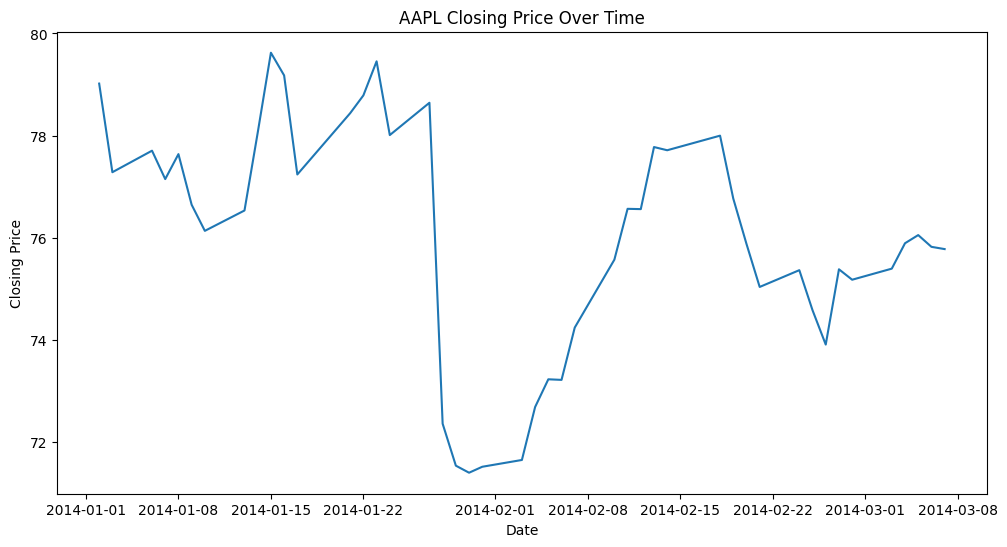

In [2]:
plt.figure(figsize=(12,6))
plt.plot(aapl['date'], aapl['close'])
plt.title('AAPL Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.show()

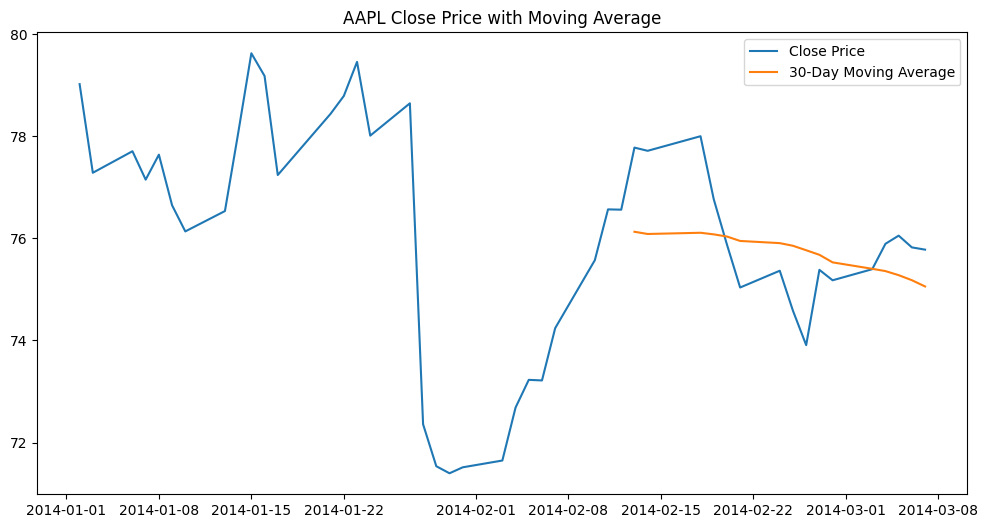

In [3]:
aapl['MA_30'] = aapl['close'].rolling(window=30).mean()

plt.figure(figsize=(12,6))
plt.plot(aapl['date'], aapl['close'], label='Close Price')
plt.plot(aapl['date'], aapl['MA_30'], label='30-Day Moving Average')
plt.legend()
plt.title('AAPL Close Price with Moving Average')
plt.show()

In [4]:
from statsmodels.tsa.seasonal import seasonal_decompose

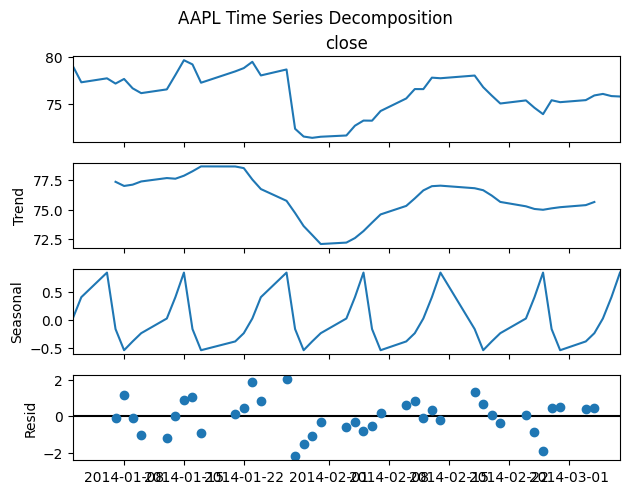

In [6]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

aapl = df[df['symbol'] == 'AAPL'].copy()
aapl['date'] = pd.to_datetime(aapl['date'])
aapl = aapl.sort_values('date')
aapl = aapl.set_index('date')

result = seasonal_decompose(
    aapl['close'],
    model='additive',
    period=7
)

result.plot()
plt.suptitle("AAPL Time Series Decomposition", y=1.02)
plt.show()